In [39]:
#installing the libraries
!pip install catboost
!pip install econml

In [40]:
#importing the libraries
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from econml.metalearners import SLearner, TLearner, XLearner
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from scipy.stats import pearsonr
import joblib
import os

In [41]:
df = pd.read_csv("/content/simulated_uplift_data.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureBucket,FamilyIndicator,SupportBundle,StreamingBundle,Treatment_Prob,Treatment,TreatmentEffect,BaseProb,TreatedProb,Y0,Y1,Outcome
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,1,1,0,0.5,1,0.2,0.35,0.15,1,1,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-4 Years,0,2,0,0.3,1,0.1,0.15,0.05,1,1,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,0,2,0,0.5,1,0.2,0.35,0.15,0,1,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4 Years,0,3,0,0.3,1,0.1,0.05,0.01,1,1,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,0,0,0,0.5,0,0.2,0.35,0.15,0,1,0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
target_col = "Outcome"
treatment_col = "Treatment"
meta_cols = ["Y0", "Y1"] #helper columns

'''Y0 is retention without treatment/Y1 retention with treatment
suppose treatment is 1 then Y1 will be chosen as outcome
suppose treatment is 0 then Y0 will be chosen as outcome '''

feature_cols = [c for c in df.columns if c not in [target_col, treatment_col] + meta_cols]

X = df[feature_cols]
y = df[target_col]
t = df[treatment_col]

# encode
X_encoded = pd.get_dummies(X, drop_first=True)
'''drop_first=True removes one dummy column for each categorical feature because
the dropped category can be inferred from the remaining dummy columns, reducing
redundancy and avoiding the dummy variable trap.'''
feature_columns = X_encoded.columns.tolist()
X_encoded = X_encoded.reindex(columns=feature_columns, fill_value=0)
#Make my dataframe have exactly these columns, in this exact order fill_value=0 fills every missing value with 0


In [44]:
os.makedirs("/content/models", exist_ok=True)

In [45]:
joblib.dump(feature_columns, "/content/models/feature_columns.pkl")

['/content/models/feature_columns.pkl']

In [46]:
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X_encoded,y, t, test_size=0.2, random_state=42
)

In [47]:
base_model = CatBoostRegressor(
    depth=6,
    iterations=500,
    learning_rate=0.05,
    verbose=0
)

In [48]:
s_learner = SLearner(overall_model=base_model)

s_learner.fit(y_train, t_train, X=X_train.values)

In [49]:
t_learner = TLearner(models=base_model)

t_learner.fit(y_train, t_train, X=X_train.values)

In [50]:
x_learner = XLearner(models=base_model)

x_learner.fit(y_train, t_train, X=X_train.values)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


evaluation

In [51]:
df_test = df.loc[X_test.index].copy()
df_test["true_uplift"] = df_test["BaseProb"] - df_test["TreatedProb"]

In [52]:
s_pred = s_learner.effect(X_test.values)
t_pred = t_learner.effect(X_test.values)
x_pred = x_learner.effect(X_test.values)

In [53]:

#pearsonr() returns a tuple (correlation, p_value) so to access correlation [0]
print("S-Learner:", pearsonr(df_test["true_uplift"], s_pred)[0])
print("T-Learner:", pearsonr(df_test["true_uplift"], t_pred)[0])
print("X-Learner:", pearsonr(df_test["true_uplift"], x_pred)[0])


S-Learner: 0.8520622423771735
T-Learner: 0.8463170402471758
X-Learner: 0.8770391079312676


In [54]:
from sklearn.metrics import mean_absolute_error

print("S MAE:", mean_absolute_error(df_test["true_uplift"], s_pred))
print("T MAE:", mean_absolute_error(df_test["true_uplift"], t_pred))
print("X MAE:", mean_absolute_error(df_test["true_uplift"], x_pred))

S MAE: 0.04565624735136908
T MAE: 0.039945855285047564
X MAE: 0.03942181986031605


found that x learner is performing well so performing correlation,mae and rmse

In [55]:
uplift_pred = x_learner.effect(X_test)
uplift_pred = np.array(uplift_pred).reshape(-1)

In [56]:
df_test["uplift_pred"] = uplift_pred



In [57]:


corr, p_value = pearsonr(
    df_test["true_uplift"],
    df_test["uplift_pred"]
)

print("Correlation:", corr)

Correlation: 0.8770391079312676


In [58]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    df_test["true_uplift"],
    df_test["uplift_pred"]
)

print("MAE:", mae)

MAE: 0.03942181986031605


In [59]:


rmse = root_mean_squared_error(
    df_test["true_uplift"],
    df_test["uplift_pred"]
)

print("RMSE:", rmse)

RMSE: 0.055938265870015054


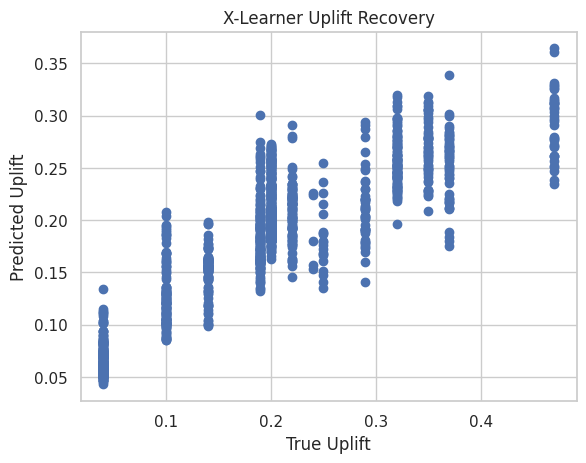

In [60]:


plt.scatter(
    df_test["true_uplift"],
    df_test["uplift_pred"]
)

plt.xlabel("True Uplift")
plt.ylabel("Predicted Uplift")
plt.title("X-Learner Uplift Recovery")

plt.show()

A good model will show points roughly following a diagonal trend.

In [61]:
#ATE CALCULATION(Average Treatment Effect)
ATE = np.mean(uplift_pred)
print(ATE)

0.18009456814813946


In [62]:
joblib.dump(x_learner, "/content/models/xlearner.pkl")

['/content/models/xlearner.pkl']

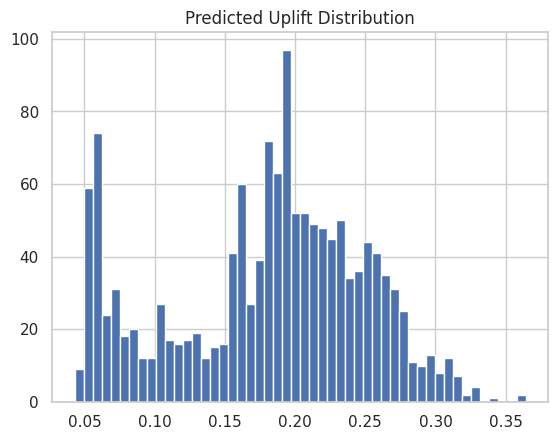

In [63]:
plt.hist(df_test["uplift_pred"], bins=50)
plt.title("Predicted Uplift Distribution")
plt.show()

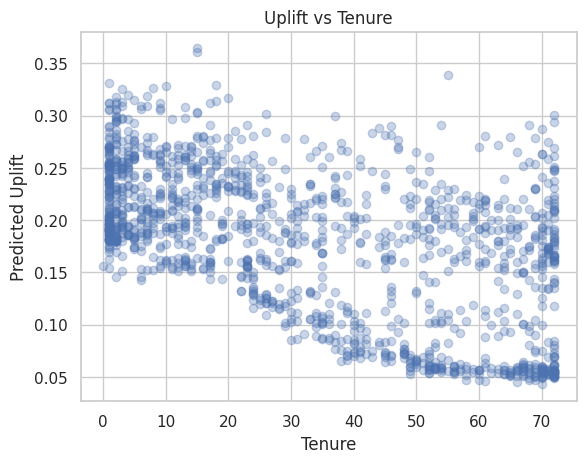

In [64]:
plt.scatter(df_test["tenure"], df_test["uplift_pred"], alpha=0.3)
plt.title("Uplift vs Tenure")
plt.xlabel("Tenure")
plt.ylabel("Predicted Uplift")
plt.show()

now applying the xlearner to original dataset and adding features uplift_pred,policy and segment

In [65]:
all_uplift = x_learner.effect(X_encoded)
all_uplift = np.array(all_uplift).reshape(-1)

df["uplift_pred"] = all_uplift

def segment(x):
    if x > 0.2:
        return "Persuadable"
    elif x > 0:
        return "Sleeping Dogs"
    elif x > -0.2:
        return "Sure Things"
    else:
        return "Lost Causes"

df["segment"] = df["uplift_pred"].apply(segment)

In [66]:
df["uplift_pred"].describe()

,uplift_pred
count,7043.000000
mean,0.180391
std,0.070481
min,-0.147933
25%,0.136576
50%,0.188602
75%,0.228929
max,0.407149


In [67]:
df.groupby("Treatment")["uplift_pred"].mean()

,uplift_pred
Treatment,
0,0.169561
1,0.192633


In [68]:
df.groupby("segment")["MonthlyCharges"].mean()

,MonthlyCharges
segment,
Persuadable,80.148655
Sleeping Dogs,54.024716
Sure Things,40.135000


In [69]:
df.groupby("segment")["tenure"].mean()

,tenure
segment,
Persuadable,22.596207
Sleeping Dogs,39.181224
Sure Things,52.500000


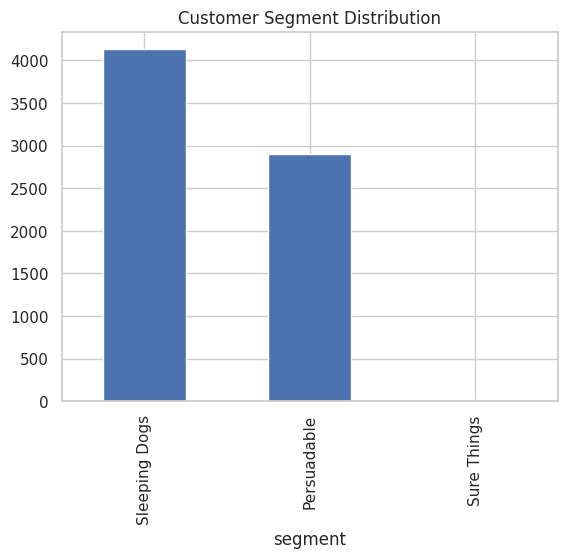

In [70]:
df["segment"].value_counts().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.show()

In [71]:
df.to_csv("x_learner_training.csv", index=False)